In [1]:
import numpy as np
import math
from collections import namedtuple
from tqdm.autonotebook import tqdm
import emcee
from multiprocessing import Pool
# Number of parameters
import matplotlib.pyplot as plt
import os
import re
import pandas as pd
from pathlib import Path

# import own modules
import functions as lf
import radar_functions as rf
from data_structures import ObsData, LightCurve, PartialLightCurve
from mcmc import ln_prob, ln_prior, ln_posterior, theor_curve, ln_wrapper, ln_prob_both, ln_prob_radar
from scipy.optimize import minimize, differential_evolution

/tmp/ipykernel_63726/986939098.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
def ln_abs(params: tuple, radar_image_list, radar_images: list, position_vecs,
               lightcurve: LightCurve, earth_data: ObsData, sun_data: ObsData, params_min, params_max):
    res = ln_prob_both(params, radar_image_list, radar_images, position_vecs,
                      lightcurve, earth_data, sun_data, params_min, params_max)
    if res != -np.inf:
        return abs(res)
    else:
        return np.inf

def ln_abs_lc(params: tuple,
               lightcurve: LightCurve, earth_data: ObsData, sun_data: ObsData):
    res = ln_prob(params, lightcurve, earth_data, sun_data)
    if res != -np.inf:
        return abs(res)
    else:
        return np.inf

def ln_abs_radar(params: tuple, radar_image_list, radar_images: list, position_vecs):
    res = ln_prob_radar(params, radar_image_list, radar_images, position_vecs)
    if res != -np.inf:
        return abs(res)
    else:
        return np.inf

ln_abs_wrap = rf.CallbackFunctor(ln_abs)

In [3]:
# get state vectors of the Earth and the Sun from JPL Horizons database
asteroid_name = "2000 WO107" 
lightcurve = LightCurve()  # container to store partial lightcurves
earth_data = ObsData()     # store earth vectors
sun_data = ObsData()       # store sun vectors
# get names of the lightcurve files
directory_lc = 'lightcurves/lc_krug_warner'
#read warner data in csv format
fnames_warner = [f for f in os.listdir(directory_lc) if re.match(r'.*\.csv', f)]
fnames_warner.sort()
for idx, fname in enumerate(fnames_warner):
    # read the base time of the partial lightcurve
    part_curve = pd.read_csv(f'{directory_lc}/{fname}')#, header=None, names=['epoch', 'ut_time', 'mag', 'mag_err'], skiprows=3, sep=' ')
    part_curve['epoch'] = part_curve['epoch'].astype(float)
    part_curve.astype(float)
    part_curve['mag_err'] *= 3
    lightcurve += PartialLightCurve(part_curve, fname=Path(fname).stem)

fnames = [f for f in os.listdir(directory_lc) if re.match(r'.*\.DAT', f)]
fnames.sort()
# read and parse partial lightcurve files
for idx, fname in enumerate(fnames):
    # read the base time of the partial lightcurve
    part_curve = pd.read_csv(f'{directory_lc}/{fname}', header=None, names=['epoch', 'ut_time', 'mag', 'mag_err'], skiprows=3, sep=' ')
    part_curve['epoch'] = part_curve['epoch'].astype(float)
    part_curve.astype(float)
    lightcurve += PartialLightCurve(part_curve, fname=Path(fname).stem)

# sort lightcurves in the ascending order of the epoch
lightcurve.sort_lightcurves()
start_epoch = lightcurve.joined['epoch'].min()
reduc_epochs = lightcurve.joined['epoch'] - start_epoch
for i in range(len(lightcurve)):
    lightcurve.lightcurves[i].data['weight'] = (lightcurve.lightcurves[i].data['weight']
                                                / len(lightcurve.lightcurves[i]) * (len(lightcurve.joined) / len(lightcurve)))

In [4]:
lightcurve#.enum_curves()

LightCurve (contains 21 partial lightcurves)

In [5]:
lightcurve.join_lightcurves()
lightcurve.joined

,epoch,ut_time,mag,mag_err,weight,curve_idx
0,2.459182e+06,19.9177,13.016,0.057,0.868036,0
1,2.459182e+06,19.9265,12.959,0.060,0.868036,0
2,2.459182e+06,19.9354,12.987,0.063,0.868036,0
3,2.459182e+06,19.9443,13.047,0.070,0.868036,0
4,2.459182e+06,19.9532,13.104,0.070,0.868036,0
...,...,...,...,...,...,...
2784,2.459196e+06,NaN,16.818,0.096,1.819309,20
2785,2.459196e+06,NaN,16.888,0.135,1.819309,20
2786,2.459196e+06,NaN,16.965,0.153,1.819309,20
2787,2.459196e+06,NaN,16.956,0.102,1.819309,20


In [6]:
# query JPL Horizons to get state vectors of the Sun and the Earth
for part_curve in tqdm(lightcurve, total=len(lightcurve), desc='Querying JPL Horizons'):
    epochs = part_curve.data.epoch.to_list()
    state_vecs_sun = lf.get_object_orbit(asteroid_name, epochs=epochs,  location='@10', data_type='vectors').reset_index(drop=True)
    # @399 - Earth
    state_vecs_earth = lf.get_object_orbit(asteroid_name, epochs=epochs,  location='@399', data_type='vectors').reset_index(drop=True)
    # calculate reduc epoch (counting from start epoch)
    # calculate distance between the Earth and the asteroid
    state_vecs_earth['distance'] = (state_vecs_earth['x']**2 + state_vecs_earth['y']**2 + state_vecs_earth['z']**2)**0.5
    # calulate lighttime (in AU)
    state_vecs_earth['lighttime'] = state_vecs_earth['distance'] / 86400 / 299792458 * 149597870700
    state_vecs_sun['reduc_epoch'] = state_vecs_sun['epoch'] - start_epoch
    state_vecs_earth['reduc_epoch'] = state_vecs_earth['epoch'] - start_epoch  - state_vecs_earth['lighttime']
    # inverse signs of vectors
    state_vecs_sun[['x', 'y', 'z']] = -state_vecs_sun[['x', 'y', 'z']]
    state_vecs_earth[['x', 'y', 'z']] = -state_vecs_earth[['x', 'y', 'z']]
    sun_data += state_vecs_sun
    earth_data += state_vecs_earth

Querying JPL Horizons:   0%|          | 0/21 [00:00<?, ?it/s]

In [7]:
earth_data.join_data()
earth_data.joined

,name,x,y,z,vx,vy,vz,epoch,distance,lighttime,reduc_epoch
0,153201 (2000 WO107),0.022036,-0.019195,0.002045,0.011308,0.008935,0.001368,2.459182e+06,0.029296,0.000169,-0.000169
1,153201 (2000 WO107),0.022032,-0.019198,0.002045,0.011308,0.008935,0.001368,2.459182e+06,0.029295,0.000169,0.000201
2,153201 (2000 WO107),0.022028,-0.019202,0.002044,0.011308,0.008935,0.001368,2.459182e+06,0.029294,0.000169,0.000571
3,153201 (2000 WO107),0.022024,-0.019205,0.002044,0.011308,0.008935,0.001368,2.459182e+06,0.029293,0.000169,0.000941
4,153201 (2000 WO107),0.022019,-0.019208,0.002043,0.011308,0.008935,0.001368,2.459182e+06,0.029292,0.000169,0.001311
...,...,...,...,...,...,...,...,...,...,...,...
2784,153201 (2000 WO107),-0.131647,-0.142979,-0.016353,0.011394,0.009573,0.001345,2.459196e+06,0.195041,0.001126,13.518163
2785,153201 (2000 WO107),-0.131680,-0.143006,-0.016357,0.011394,0.009573,0.001345,2.459196e+06,0.195084,0.001127,13.521059
2786,153201 (2000 WO107),-0.131713,-0.143034,-0.016361,0.011394,0.009573,0.001345,2.459196e+06,0.195127,0.001127,13.523955
2787,153201 (2000 WO107),-0.131746,-0.143062,-0.016365,0.011394,0.009573,0.001345,2.459196e+06,0.195170,0.001127,13.526850


In [8]:
radar_image_params = rf.RadarImageParameters("radar_data/data.txt")
# radar_images_obs = [np.array(read_observed_radar_image(radar_image_params,idx_img)) for idx_img in range(radar_image_params.N_points)]
radar_images_obs = [rf.denoise_img(np.array(rf.read_observed_radar_image(radar_image_params,idx_img)))
                    for idx_img in range(radar_image_params.N_points)]


query_dates = [radar_image_params.jd[idx_img] + 2400000.5 for idx_img in range(len(radar_image_params.jd))]
state_vecs_earth = lf.get_object_orbit('2000 WO107', epochs=query_dates,  location='@399', data_type='vectors')
state_vecs_earth['r'] = np.sum(state_vecs_earth[['x', 'y', 'z']] ** 2, axis=1)**0.5
position_vecs = (state_vecs_earth[['x', 'y', 'z']].T / state_vecs_earth['r']).T
#position_vecs.to_csv('input_data/position_vecs.csv', index=False)

In [9]:
params = [1, 0.9, 0.86, 1, 0.85, 0.83, 2, -1.5, 2.2, 0.2091, 2000, 2]
radar_images_idxs = [i for i in range(0, 71)]
lightcurve_idxs = [i for i in range(len(lightcurve))]
res_params = []

In [11]:
# Define the named tuple
ParameterBounds = namedtuple('ParameterBounds', ['a1', 'b1', 'c1', 'a2', 'b2', 'c2', 'lon', 'lat', 'init_phase', 'rot_period', 'radar_saturation', 'pow_coeff'])

# Create an instance of the named tuple with the bounds
param_bounds=ParameterBounds(a1=[0.9, 2.1], b1=[0.8, 1.2], c1=[0.5, 1.2],
                             a2=[0.45, 1.45], b2=[0.57, 1.4], c2=[0.2, 1.4],
                             lon=[0, 2*math.pi], lat=[-2.1, -0.4], init_phase=[0, 2*math.pi],
                             rot_period=[5.022 * 0.9 / 24, 5.022 * 1.1 / 24],
                             radar_saturation=[1000, 2500], pow_coeff=[1.75, 2.25])

print(param_bounds)

ParameterBounds(a1=[0.9, 2.1], b1=[0.8, 1.2], c1=[0.5, 1.2], a2=[0.45, 1.45], b2=[0.57, 1.4], c2=[0.2, 1.4], lon=[0, 6.283185307179586], lat=[-2.1, -0.4], init_phase=[0, 6.283185307179586], rot_period=[0.188325, 0.23017500000000002], radar_saturation=[1000, 2500], pow_coeff=[1.75, 2.25])


In [10]:
# optimize only radar
# optimize both lightcurves and radar images
max_repeats = 1
bootstrap_frac = 0.5
for idx in tqdm(range(max_repeats)):
    ln_abs_wrap = ln_abs
    np.random.seed(idx + 10)
    # select data which will be used in MCMC
    selected_radar_idx = sorted(np.random.choice(radar_images_idxs, 35, replace=False))
    selected_radar_imgs = [radar_images_obs[s_idx] for s_idx in selected_radar_idx]
    # create new function instance
    res_diff = differential_evolution(ln_abs_radar, param_bounds, args=(
                                                                 radar_image_params[selected_radar_idx],
                                                                 selected_radar_imgs,
                                                                 position_vecs.iloc[selected_radar_idx]),# callback=ln_abs_wrap,
                                  disp=True, x0=params, maxiter=50, workers=6)
    res_params.append([[round(x, 4) for x in res_diff.x], res_diff.fun])


  0%|          | 0/1 [00:00<?, ?it/s]

/home/ihor/miniconda3/envs/sandbox/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 2095.2737742467184
differential_evolution step 2: f(x)= 2095.2737742467184
differential_evolution step 3: f(x)= 2095.2737742467184
differential_evolution step 4: f(x)= 1843.3639751585913
differential_evolution step 5: f(x)= 1843.3639751585913
differential_evolution step 6: f(x)= 1467.5479650613559
differential_evolution step 7: f(x)= 1467.5479650613559
differential_evolution step 8: f(x)= 1467.5479650613559
differential_evolution step 9: f(x)= 1467.5479650613559
differential_evolution step 10: f(x)= 1467.5479650613559
differential_evolution step 11: f(x)= 1467.5479650613559
differential_evolution step 12: f(x)= 1467.5479650613559
differential_evolution step 13: f(x)= 1467.5479650613559
differential_evolution step 14: f(x)= 1467.5479650613559
differential_evolution step 15: f(x)= 1462.5442583803338
differential_evolution step 16: f(x)= 1462.5442583803338
differential_evolution step 17: f(x)= 1462.5442583803338
differential_evolution step 18: f(x)= 14

/home/ihor/miniconda3/envs/sandbox/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


In [12]:
# optimize both lightcurves and radar images
max_repeats = 1
bootstrap_frac = 1.0
params_min = np.zeros(12)
params_max = np.ones(12)
for idx in tqdm(range(max_repeats)):
    ln_abs_wrap = ln_abs
    np.random.seed(idx + 10)
    # select data which will be used in MCMC
    selected_radar_idx = sorted(np.random.choice(radar_images_idxs, 71, replace=False))
    selected_radar_imgs = [radar_images_obs[s_idx] for s_idx in selected_radar_idx]
    # select data which will be used in MCMC
    bt_lcs = LightCurve([PartialLightCurve(rf.bootstrap_lightcurve(lightcurve=lc, frac=bootstrap_frac)) for lc in lightcurve.lightcurves])
    bt_idxs = [rf.get_bootstrap_idxs(lc) for lc in bt_lcs.lightcurves]
    bt_earth_data = ObsData([earth_data[idx].iloc[bt] for idx, bt in enumerate(bt_idxs)])
    bt_sun_data = ObsData([sun_data[idx].iloc[bt] for idx, bt in enumerate(bt_idxs)])
    # create new function instance
    res_diff = differential_evolution(ln_abs_wrap, param_bounds, args=(
                                                                 radar_image_params[selected_radar_idx],
                                                                 selected_radar_imgs,
                                                                 position_vecs.iloc[selected_radar_idx],
                                          bt_lcs, bt_earth_data, bt_sun_data, params_min, params_max),# callback=ln_abs_wrap,
                                  disp=True, x0=params, maxiter=200, workers=6)
    res_params.append([[round(x, 4) for x in res_diff.x], res_diff.fun])

  0%|          | 0/1 [00:00<?, ?it/s]

/home/ihor/miniconda3/envs/sandbox/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 483630.6524921679
differential_evolution step 2: f(x)= 323399.93036935583
differential_evolution step 3: f(x)= 323399.93036935583
differential_evolution step 4: f(x)= 323399.93036935583
differential_evolution step 5: f(x)= 295539.53342348896
differential_evolution step 6: f(x)= 243912.70762676114
differential_evolution step 7: f(x)= 243912.70762676114
differential_evolution step 8: f(x)= 243466.3857365098
differential_evolution step 9: f(x)= 180202.4315331478
differential_evolution step 10: f(x)= 180202.4315331478
differential_evolution step 11: f(x)= 180202.4315331478
differential_evolution step 12: f(x)= 180202.4315331478
differential_evolution step 13: f(x)= 180202.4315331478
differential_evolution step 14: f(x)= 180202.4315331478
differential_evolution step 15: f(x)= 180202.4315331478
differential_evolution step 16: f(x)= 180202.4315331478
differential_evolution step 17: f(x)= 180202.4315331478
differential_evolution step 18: f(x)= 180202.431533

Process ForkPoolWorker-3:
Process ForkPoolWorker-4:
Process ForkPoolWorker-2:
Process ForkPoolWorker-5:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/ihor/miniconda3/envs/sandbox/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
Process ForkPoolWorker-6:
  File "/home/ihor/miniconda3/envs/sandbox/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/ihor/miniconda3/envs/sandbox/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/ihor/miniconda3/envs/sandbox/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/ihor/miniconda3/envs/sandbox/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/ihor/miniconda3/envs/sandbox/lib/python3.12/multiprocessing/po

KeyboardInterrupt: 

In [13]:
res_params

[]

In [12]:
n_procs = 4  # number of processes (cores) to use
nwalkers = n_procs * 10  # number of probe points (walkers)

coeff = 0.2  # Increase to spread walkers more

init_ps = [1.4, 0.9, 0.8, 1.0, 0.8, 0.7, 1e-5, 1e-5, 1e-5, 0.209, 2000, 2.0]  # Avoid exact zeros
init_params = np.array([
    init_ps[0]  + coeff * np.random.randn(nwalkers),  # a1
    init_ps[1]  + coeff/2 * np.random.randn(nwalkers),  # b1
    init_ps[2]  + coeff/2 * np.random.randn(nwalkers),  # c1
    init_ps[3]  + coeff*1.1 * np.random.randn(nwalkers),  # a2
    init_ps[4]  + coeff * np.random.randn(nwalkers),  # b2
    init_ps[5]  + coeff/1.2 * np.random.randn(nwalkers),  # c2
    np.random.uniform(low=1e-5, high=2 * math.pi, size=nwalkers),  # lon
    np.random.uniform(low=-math.pi /2, high=math.pi /2, size=nwalkers),  # lat
    np.random.uniform(low=1e-5, high=2 * math.pi, size=nwalkers),  # phase
    np.random.uniform(low=5.022 / 24 * 0.95, high=5.022 / 24 * 1.05, size=nwalkers),  # rot_period
    np.random.uniform(low=1500, high=2500, size=nwalkers),  # init_phase
    np.random.uniform(low=1.75, high=2.25, size=nwalkers)  # last parameter
]).T  # Transpose to get (nwalkers, ndim)

ndim = np.size(init_params, axis=1)

# Normalize parameters
params_min = init_params.min(axis=0)
params_max = init_params.max(axis=0)
normalized_params = (init_params - params_min) / (params_max - params_min)
# mean_params = np.mean(init_params, axis=0)
# std_params = np.std(init_params, axis=0)
# init_params = (init_params - mean_params) / std_params

print(normalized_params.shape)  # Should be (nwalkers, ndim)


(40, 12)


In [13]:
with Pool(processes=n_procs) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, ln_prob_both,
                                    args=(radar_image_params, radar_images_obs, position_vecs,
                                          lightcurve, earth_data, sun_data, params_min, params_max),
                                    pool=pool,
                                    #moves=emcee.moves.GaussianMove(cov=cov_mat))
                                    moves=[
                                        (emcee.moves.DEMove(gamma0=0.7), 0.6),  # Reduce gamma0 (step size) =0.7
                                        (emcee.moves.StretchMove(), 0.2),
                                        (emcee.moves.DESnookerMove(), 0.2)
                                    ]
                                    )
    # Run the MCMC sampler
    nsteps = 500
    burn_in = 100
    # starting points for every walker
    #init_p = np.random.rand(nwalkers, ndim)
    pos, prob, state = sampler.run_mcmc(normalized_params, nsteps, progress=True)
    # Get the samples after burn-in
    samples = sampler.get_chain(discard=burn_in, flat=True)

# Plot the scatter plot of data and fitted model
best_fit_params = np.median(samples, axis=0)
#best_fit_params = np.insert(best_fit_params, 0, 1.0)
fit_curve = theor_curve(best_fit_params[:10], earth_data, sun_data)

  0%|          | 0/500 [00:00<?, ?it/s]/home/ihor/miniconda3/envs/sandbox/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  2%|▏         | 9/500 [00:13<12:08,  1.48s/it]

emcee: Exception while calling your likelihood function:
  params: emcee: Exception while calling your likelihood function:[0.68818881 0.59054873 0.54100469 0.43067987 0.37188321 0.51488343
 0.55783274 0.19886133 0.57679825 0.30590885 0.34265207 0.56276735]emcee: Exception while calling your likelihood function:


  args:  params:  params: emcee: Exception while calling your likelihood function:  
[ 0.2624291   0.39281342 -0.01830333  0.6154362   0.45845243  0.41386472
  0.84500048  0.13796161  0.99713704  0.62142426  0.02196682  0.47521325]  params:[0.76112473 0.57857011 0.5500975  0.34855166 0.31651314 0.45220019
 0.65499064 0.05173664 0.61820161 0.14410718 0.39699292 0.63785423]
   args:
  args:[0.66618163 0.6424758  0.55580993 0.51215724 0.35848107 0.61444225
 0.84339404 0.0527272  0.4996948  0.89629363 0.34181508 0.8529854 ] 
   args: 



KeyboardInterrupt



In [ ]:
best_fit_params = np.nanmedian(samples, axis=0)
best_fit_params = best_fit_params * (params_max - params_min) + params_min#* std_params + mean_params
print(best_fit_params)
sampler.params_max = params_max
sampler.params_min = params_min

In [10]:
# import pickle
# file_pick = open('mcmc_samples_2025/both_mcmc_24_02_2025_warner.obj', 'wb')
# pickle.dump(sampler, file=file_pick)

NameError: name 'sampler' is not defined

In [11]:
import pickle
file_pick = open('mcmc_samples_2025/both_mcmc_24_02_2025_warner.obj', 'rb')
sampler = pickle.load(file_pick)

In [13]:
samples_flat = sampler.flatchain * (sampler.params_max - sampler.params_min) + sampler.params_min#* std_params + mean_params
samples = sampler.get_chain(flat=True) * (sampler.params_max - sampler.params_min) + sampler.params_min#* std_params + mean_params
flat_ln = sampler.flatlnprobability#[np.isfinite(sampler.flatlnprobability)]
samples = samples[np.argwhere(flat_ln != -np.inf), :][:, 0]
min_arg = flat_ln.argmax()
min_chi = flat_ln[min_arg]
print(f'len_samples_all: {len(samples_flat)}', f'len_samples_notna: {len(samples)}')
print(f"min_arg: {min_arg}, min_chi: {min_chi}")
best_params = samples_flat[min_arg]
#best_params = np.insert(best_params, 0, 1.0)
print("""best_params: a1 = {:.2f},  b1 = {:.2f}, c1 = {:.2f},
             a2 = {:.2f}, b2 = {:.2f}, c2 = {:.2f},
             lon = {:.2f}, lat = {:.2f}, phase = {:.2f}""".format(*best_params))


print('best:      ', [round(float(param), 4) for param in best_params])

len_samples_all: 8000000 len_samples_notna: 7913882
min_arg: 7531914, min_chi: -42374.84370039749
best_params: a1 = 1.40,  b1 = 0.83, c1 = 0.83,
             a2 = 1.04, b2 = 1.04, c2 = 0.38,
             lon = 1.40, lat = -1.39, phase = 1.67
best:       [1.4029, 0.8311, 0.8263, 1.0421, 1.0401, 0.3781, 1.3984, -1.3909, 1.6711, 0.2091, 2344.2644, 2.0228]


/home/ihor/PycharmProjects/Binary_MCMC/radar_functions.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, h_pad=-0.4, w_pad=0.0)


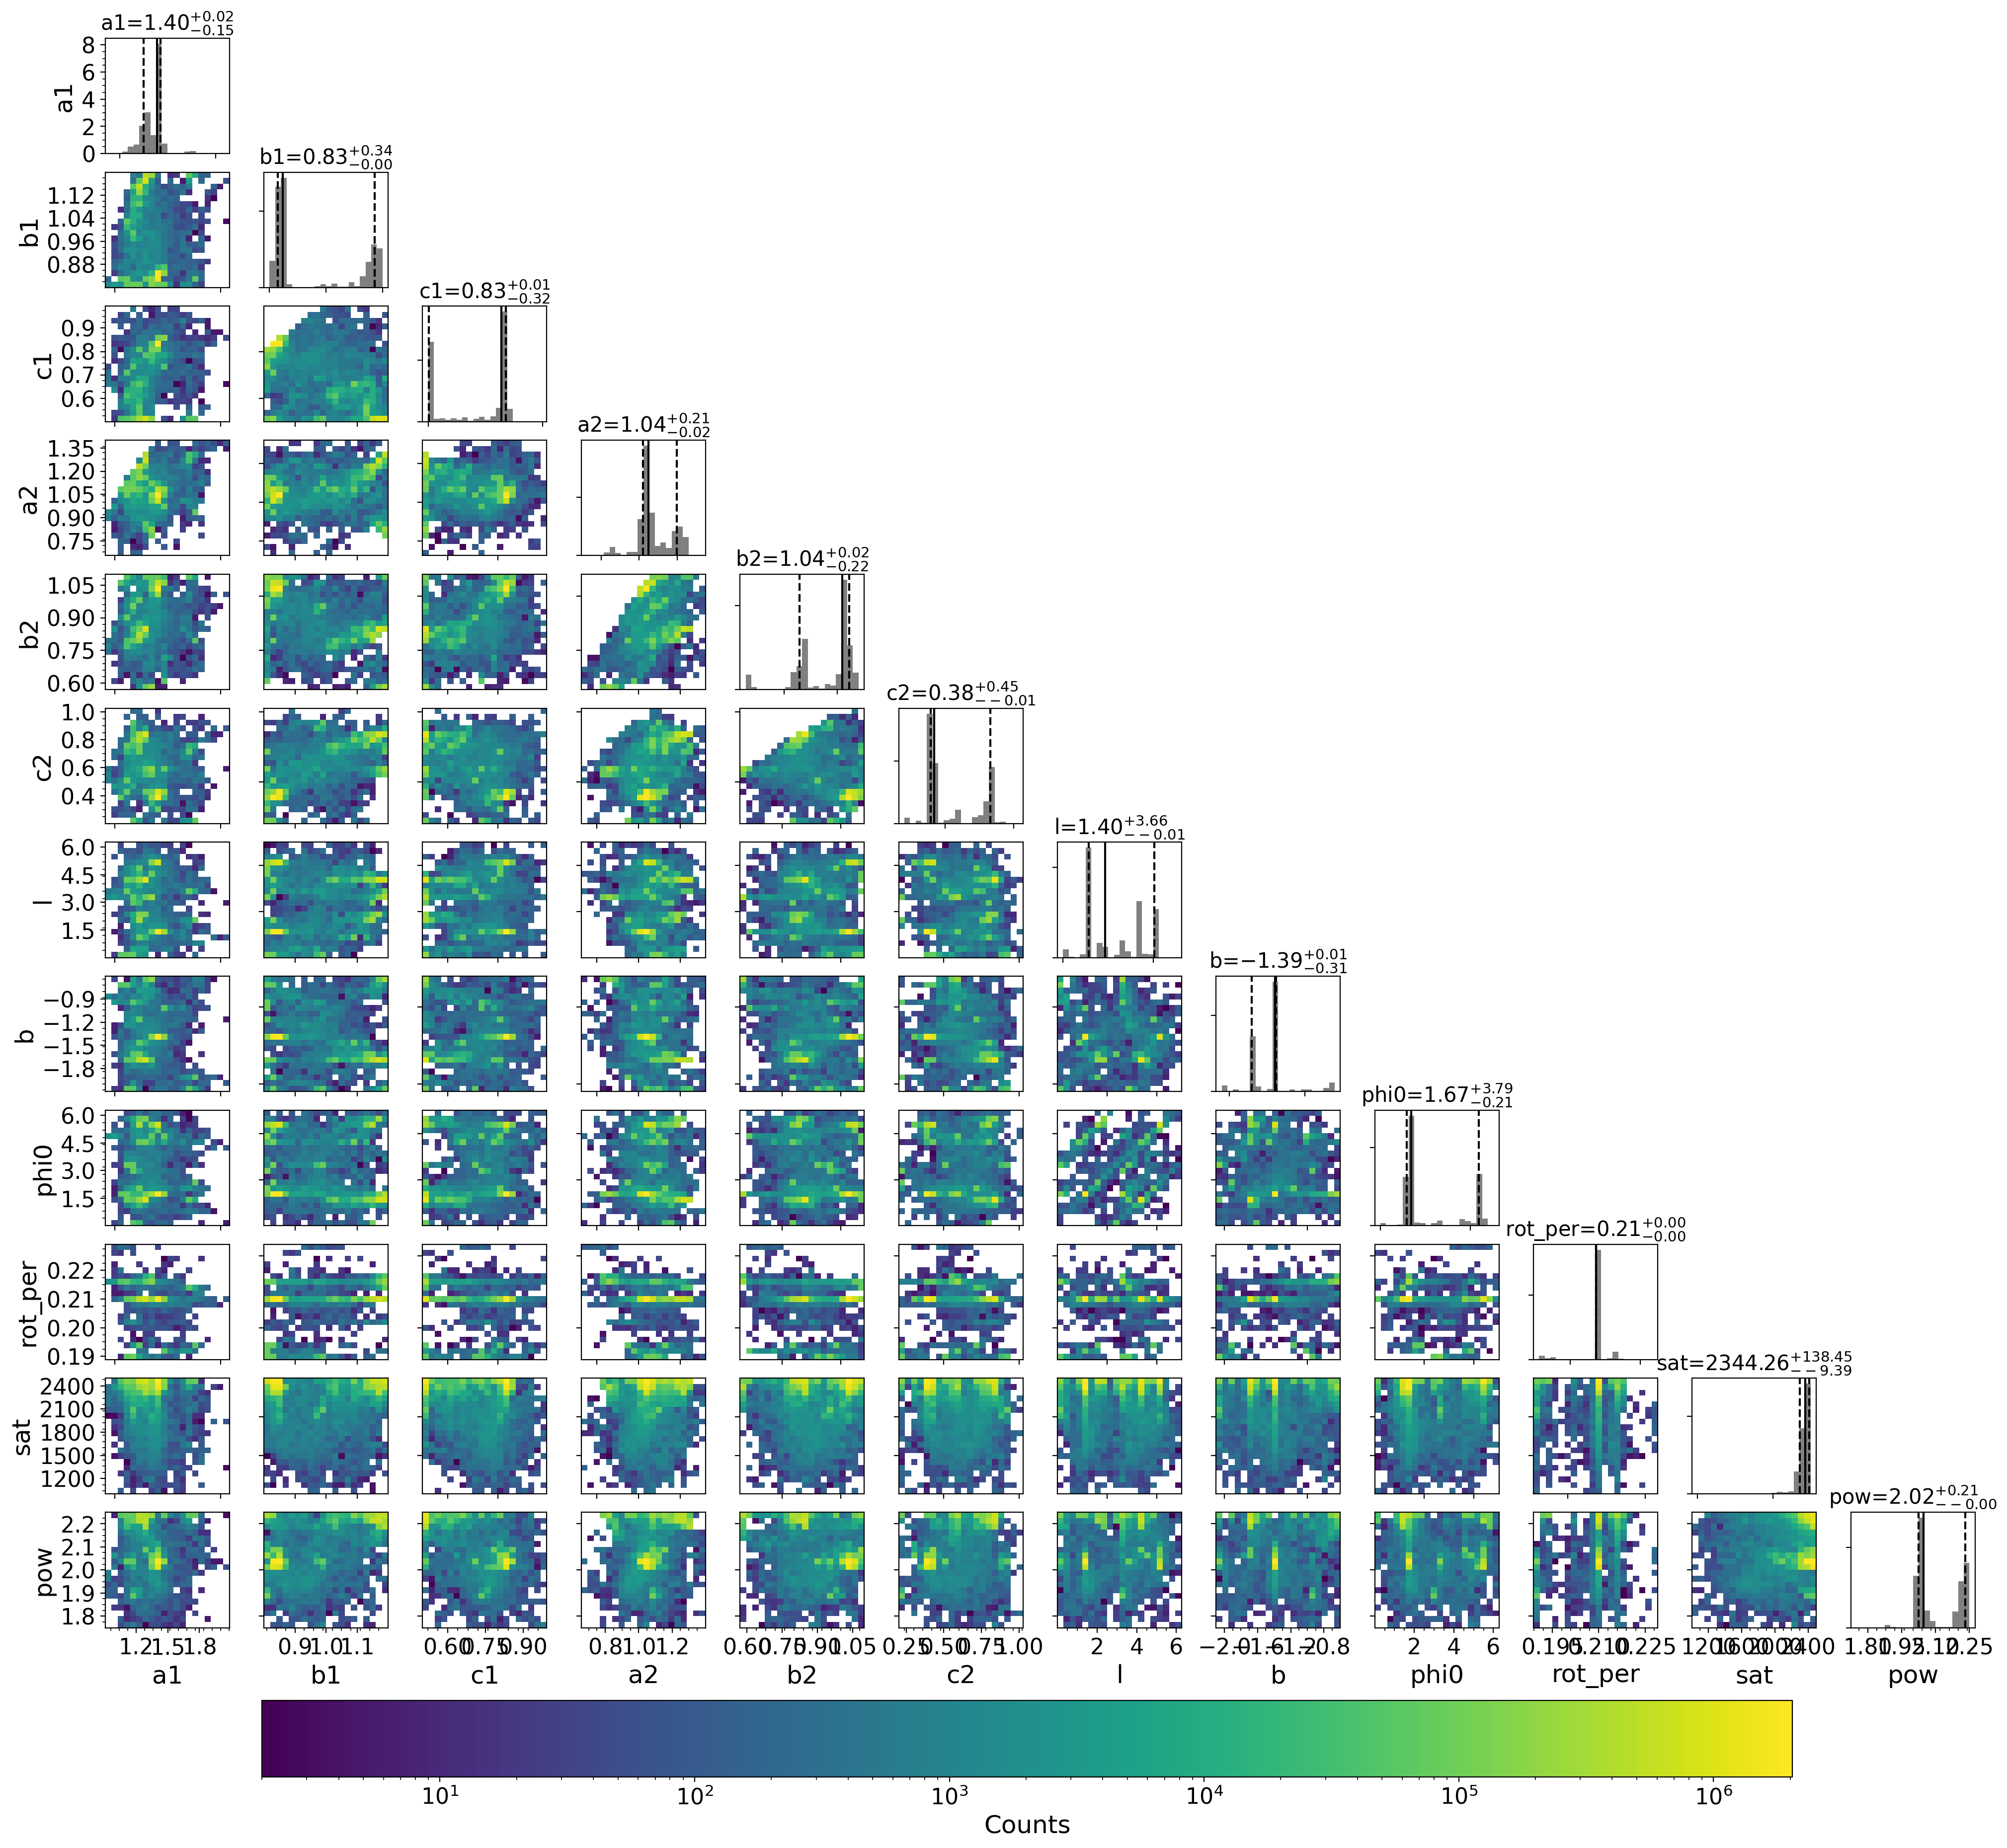

In [14]:
labels=["a1", "b1", "c1", "a2", "b2", "c2", "l", "b", "phi0", 'rot_per', 'sat', 'pow']
data = samples[:, :]
fig, ax = rf.build_cornerplot(data, best_params,
                           labels, bins=20, figsize=(20, 20), dpi=200)
# pow 1 - 3.0, step = 0.5

In [10]:
# Number of parameters
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.patches import Ellipse

def adjust_angle_single(data):
    if data[7] < -np.pi/2:
        data[6] = data[6] + np.pi
    if data[6] > 2*np.pi:
        data[6] = data[6] - 2*np.pi
    if data[7] < -np.pi/2:
        data[7] = -np.pi - data[7]
    if data[7] > -1.05:
        data[7] = -1
    return data

def adjust_angle(params):
    # adjust lambdas
    lambdas = params[:, 6]
    betas = params[:, 7]
    # lambdas = np.where(betas < -np.pi/2, lambdas + np.pi, lambdas)
    # lambdas = np.where(lambdas > 2*np.pi, lambdas - 2*np.pi, lambdas)
    # adjust_beta
    betas = np.where(betas < -np.pi/2, -np.pi - betas, betas)
    betas = np.where(betas > -1.05, -1, betas)
    return np.array([lambdas, betas]).T

def calc_ellips(points):
    # Calculate the mean of the points
    mean = np.mean(points, axis=0)
    # Calculate the covariance matrix
    cov_matrix = np.cov(points, rowvar=False)
    # Calculate the eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    # Calculate the angle of the ellipse
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    # Calculate the width and height of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    return mean, width, height, angle


data = samples[:, :8]
data[:, 6:8] = adjust_angle(data)


points = np.array(results)
lc_points = np.array(lc_results)
rad_points = np.array(radar_results)
num_params = data.shape[1]

labels=["a1", "b1", "c1", "a2", "b2", "c2", "l", "b", "phi0"]

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 15
# Create a figure with subplots
fig, axes = plt.subplots(num_params, num_params, figsize=(20, 20), dpi=200)
bins_heat = 20
bins_hist = 20
best_params_hist = samples_flat[min_arg]

# Variable to store the mappable object for the colorbar
mappable = None
# Plot the histograms and scatter plots
for i in range(num_params):
    for j in range(num_params):
        if i < j:
            # Skip the upper triangle and diagonal
            axes[i, j].axis('off')
        elif i == j:
            # get the desired percentiles
            data_axis = data[:, i]
            p16 = np.percentile(data_axis, q=16)
            p84 = np.percentile(data_axis, q=84)
            median = np.median(data_axis)
            # data_axis = data_axis[(data_axis >= p16) & (data_axis <= p84)]
            # Diagonal: plot histograms
            axes[i, j].hist(data_axis, bins=bins_hist, color='gray', density=True)
            axes[i, j].axvline(median, color='black')
            axes[i, j].axvline(p16, color='black', linestyle='--')
            axes[i, j].axvline(p84, color='black', linestyle='--')
            # Add title with median and percentiles
            axes[i, j].title.set_text(r'%s=${%.2f}_{-%.2f}^{+%.2f}$' % (labels[i], round(best_params_hist[i],2),
                                                                  round(best_params_hist[i]-p16, 2), abs(round(p84 - best_params_hist[i], 2))))
        else:
            # Off-diagonal: plot scatter plots
            data_j = data[:, j]
            data_i = data[:, i]
            p16j = np.percentile(data_j, q=0)
            p84j = np.percentile(data_j, q=100)
            idx_j = np.argwhere((data_j >= p16j) & (data_j <= p84j))

            h = axes[i, j].hist2d(data_j[idx_j][:, 0], data_i[idx_j][:, 0], bins=bins_heat, cmap='viridis', norm=LogNorm())

            # plot bootstraps
            idx1, idx2 = j, i
            axes[i, j].scatter(points[:, idx1], points[:, idx2], label='both points', color='tab:red', s=25)
            # axes[i, j].scatter(lc_points[:, idx1], lc_points[:, idx2], label='lc points', color='cyan', s=25)
            # axes[i, j].scatter(rad_points[:, idx1], rad_points[:, idx2], label='radar points', color='tab:orange', s=25)
            # rad_mean, rad_width, rad_height, rad_angle = calc_ellips(np.array([rad_points[:, idx1], rad_points[:, idx2]]).T)
            # axes[i, j].add_patch(Ellipse(xy=rad_mean, width=rad_width, height=rad_height, angle=rad_angle, edgecolor='tab:orange', fc='None', lw=2, label='Uncertainty Ellipsoid'))
            # lc_mean, lc_width, lc_height, lc_angle = calc_ellips(np.array([lc_points[:, idx1], lc_points[:, idx2]]).T)
            # axes[i, j].add_patch(Ellipse(xy=lc_mean, width=lc_width, height=lc_height, angle=lc_angle, edgecolor='cyan', fc='None', lw=2, label='Uncertainty Ellipsoid'))
            mean, width, height, angle = calc_ellips(np.array([points[:, idx1], points[:, idx2]]).T)
            axes[i, j].add_patch(Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='tab:red', fc='None', lw=2, label='Uncertainty Ellipsoid'))
            if mappable is None:
                mappable = h[3]  # Store the mappable object for the colorbar
            #axes[i, j].set_xlabel(labels[j])

        # Remove labels for cleaner look
        if i < num_params - 1:
            axes[i, j].set_xticklabels([])
        if j > 0:
            axes[i, j].set_yticklabels([])

        # Add axis labels
        if i == num_params - 1:
            axes[i, j].set_xlabel(labels[j])
            axes[i, j].xaxis.set_major_locator(ticker.MaxNLocator(4))
            axes[i, j].xaxis.set_minor_locator(ticker.MaxNLocator(10))
            axes[i, j].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))
        if j == 0:
            axes[i, j].set_ylabel(labels[i])
            axes[i, j].yaxis.set_major_locator(ticker.MaxNLocator(4))
            axes[i, j].yaxis.set_minor_locator(ticker.MaxNLocator(10))
            axes[i, j].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))


# Add a colorbar at the bottom for all subplots
if mappable:
    #cbar_ax = fig.add_axes([0.09, 0.06, 0.84, 0.02])
    cbar = fig.colorbar(mappable, ax=axes, orientation='horizontal', fraction=0.03, pad=-0.23, shrink=100.0, aspect=42)
    cbar.set_label('Counts')

# Adjust layout
plt.tight_layout(pad=0.1, h_pad=-0.4, w_pad=0.0)
#plt.savefig('article_images/correlation_mcmc.png', bbox_inches='tight', format='png')
#plt.savefig('article_images/correlation_mcmc.pdf', bbox_inches='tight', format='pdf')
plt.show()

NameError: name 'samples' is not defined

In [11]:
from matplotlib.colors import LogNorm
data_sat = data[:, -1]
data_pow = data[:, -2]
p16_pow = np.percentile(data_pow, q=0)
p84_pow = np.percentile(data_pow, q=100)
idx_pow = np.argwhere((data_pow >= p16_pow) & (data_pow <= p84_pow))
bins_heat = 20
# get the indexes for the 16th and 84th percentiles
# p16i = np.percentile(data_i, q=16)
# p84i = np.percentile(data_i, q=84)
# data_i = data_i[(data_i >= p16) & (data_i <= p84)]
plt.hist2d(data_sat[idx_pow][:, 0], data_pow[idx_pow][:, 0], bins=bins_heat, cmap='viridis', norm=LogNorm())

NameError: name 'data' is not defined

chi2 mcmc: 7617.746941
chi2 degen:  9984.750309
ch2 default: 12031.333450


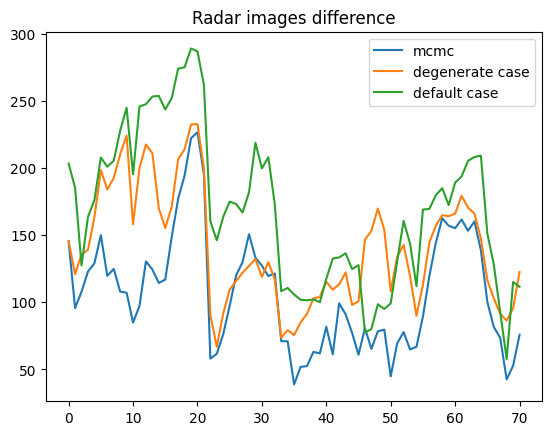

In [12]:
best_params =  [1.49796, 1.02069, 0.84324, 0.92528, 0.86996, 0.60022, 3.16461, -1.31215, 3.51913, 0.20925, 1698.94206]

boot_res9 = [[1.1678, 0.804, 0.5324, 0.816, 0.813, 0.7243, 0.0611, -1.5152, 0.3861, 0.2092, 2121.5215, 1],  # 1.0 56056.864019445624
            [1.1655, 0.8022, 0.5207, 0.8482, 0.8473, 0.6745, 0.3354, -1.5551, 0.6553, 0.2092, 2263.4688, 1.25], # 1.25 54935.45104738671
            [1.2558, 0.8237, 0.5002, 0.9791, 0.9744, 0.29, 1.2249, -1.4708, 1.5215, 0.2091, 2303.3935, 1.5], # 1.5 47470.521621185944
            [1.2784, 0.8045, 0.5761, 0.9793, 0.97, 0.3389, 1.3371, -1.4587, 1.6296, 0.2091, 2326.9029, 1.75], # 1.75 43645.63211873607
            [1.3025, 0.8147, 0.6757, 1.111, 1.0905, 0.3971, 1.2781, -1.4407, 1.5485, 0.2091, 2450.0008, 2.0], # 2.0 42102.09457413088
            [1.3296, 0.8191, 0.7735, 1.094, 1.0933, 0.4511, 1.3633, -1.4304, 1.6447, 0.2091, 1499.3876, 2.25], # 2.25 41853.33114508272
            [1.1676, 0.8034, 0.7526, 1.1067, 1.0677, 0.8267, 0.2074, -1.3648, 0.4993, 0.2091, 2252.0996, 2.5], # 2.5 42245.70398057499
            [1.1767, 0.8053, 0.7643, 1.158, 1.0984, 0.8655, 0.217, -1.3359, 0.5014, 0.2091, 1049.8886, 2.75], # 2.75 42224.61958347609
            [1.1678, 0.8075, 0.7124, 1.1316, 1.0706, 0.8284, 0.4154, -1.4249, 0.706, 0.2091, 1089.4906, 3.0]] # 3.0 43098.241524854275

results_radar_only = [
    [1.1636, 0.9273, 0.9429, 0.932, 0.5903, 0.8896, 2.8571, -1.539, 3.2335, 0.2094, 2488.2609, 1],
    [1.2405, 0.9658, 0.5074, 0.9713, 0.618, 0.4918, 0.6294, -1.5477, 0.9955, 0.2094, 2464.3381, 1.25],
    [1.3185, 1.0741, 0.5017, 0.9419, 0.7101, 0.4316, 3.3999, -1.462, 3.7435, 0.2095, 2475.8334, 1.5],
    [1.3638, 1.1444, 0.5322, 1.0198, 0.7943, 0.367, 0.2613, -1.8644, 0.5674, 0.2096, 2088.7784, 1.75],
    [1.4099, 1.162, 1.1549, 1.0501, 0.8264, 0.7296, 4.8843, -1.9093, 5.3357, 0.2092, 1970.9569, 2],
    [1.5731, 1.188, 1.156, 1.0118, 0.6434, 1.212, 1.4098, -0.9878, 1.7916, 0.2092, 1110.4474, 2.25],
    [1.782, 1.1975, 1.1557, 1.1125, 0.6283, 1.1857, 4.9929, -0.8252, 5.6508, 0.2087, 1011.1205, 2.5],
    [1.9482, 1.1986, 1.1879, 1.0948, 0.6007, 1.3264, 1.7486, -0.8682, 2.3816, 0.2087, 1001.37, 2.75],
    [2.0855, 1.1948, 1.1714, 1.3697, 1.0865, 0.6429, 1.6707, -0.6456, 2.5153, 0.2079, 1021.9279, 3]]

best_params = [1.4411, 0.808, 0.7617, 1.1215, 1.0878, 0.3172, 1.7247, -1.7429, 2.0093, 0.2091, 2259.8504, 2.0515]
#[1.28191, 1.17208, 0.50424, 1.26138, 0.83876, 0.83702, 4.29429, -1.69971, 1.43816, 0.2091, 2373.36262, 2.22369]
#best_params = results_radar_only[6]
diff_best, imgs = rf.radar_images_diff(best_params, radar_image_params, radar_images_obs, position_vecs, mult=450, lt_num=50, pow_coeff=best_params[-1])
diff_deg, imgs_deg = rf.radar_images_diff([1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 0, 0, 0, 5.022 / 24, 2000], radar_image_params,
                           radar_images_obs, position_vecs)
diff_def, imgs_def = rf.radar_images_diff([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0, 0, 0,  5.022 / 24, 2000], radar_image_params,
                           radar_images_obs, position_vecs)
plt.title('Radar images difference')
plt.plot(diff_best, label='mcmc')
plt.plot(diff_deg, label='degenerate case')
plt.plot(diff_def, label='default case')
plt.legend()
print(f'chi2 mcmc: {np.sum(diff_best):2f}',)
print(f'chi2 degen:  {np.sum(diff_deg):2f}')
print(f'ch2 default: {np.sum(diff_def):2f}')

In [13]:
def plot_radar_gray_images(imgs, radar_image_params, num_cols=3, figsize=(3, 3), dpi=100, crop=10, name_save=None, imgs_index=None):
    """
    Plot image differences with MJD labels.

    Parameters:
    imgs (list): List of image pairs (theor, obs)
    radar_image_params (object): Object containing radar image parameters
    num_rows (int): Number of rows in the plot grid
    num_cols (int): Number of columns in the plot grid
    figsize (tuple): Figure size (width, height)
    dpi (int): DPI of the plot
    crop (int): Number of pixels to crop from each edge of the image
    """
    num_rows = 1 if (len(imgs) // num_cols) == 0 else len(imgs) // num_cols
    imgs_for_one = 3


    if len(imgs) == 1:
        fig, axarr = plt.subplots(imgs_for_one*num_cols, num_rows, figsize=(figsize[0] * (imgs_for_one*num_cols), figsize[1] * num_rows), dpi=dpi)
        img_theor = imgs[0][0][crop:-crop, crop:-crop]
        img_obs = imgs[0][1][crop:-crop, crop:-crop]
        img_diff = img_obs - img_theor
        img_diff_norm = (img_diff-np.min(img_diff))/(np.max(img_diff)-np.min(img_diff))
        axarr[0].imshow(img_obs, interpolation='nearest',  cmap='gray')
        axarr[1].imshow(img_theor, interpolation='nearest',  cmap='gray')
        axarr[2].imshow(img_diff_norm, interpolation='nearest',  cmap='gray_r')
        img_shape = np.shape(img_theor)
        axarr[0].text(
                int(img_shape[0] * 0.47), int(img_shape[1] * 0.95),
                f'MJD {round(radar_image_params.jd[0], 3)}', color='white', fontsize=10)
        axarr[0].text(
                int(img_shape[0] * 0.05), int(img_shape[1] * 0.95),
                f'OBS', color='white', fontsize=10)
        axarr[1].text(
                int(img_shape[0] * 0.05), int(img_shape[1] * 0.95),
                f'MODEL', color='white', fontsize=10)
        axarr[2].text(
                int(img_shape[0] * 0.05), int(img_shape[1] * 0.95),
                f'DIFF', color='white', fontsize=10)
        plt.tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
        # remove the axis ticks
        for i in range(num_cols*imgs_for_one):
            axarr[i].set_xticks([])
            axarr[i].set_yticks([])
        # set the spacing between subplots
        plt.subplots_adjust(wspace=0.03, hspace=0.03)
    else:
        fig, axarr = plt.subplots(num_rows, imgs_for_one*num_cols, figsize=(figsize[0] * (imgs_for_one*num_cols), figsize[1] * num_rows), dpi=dpi)
        for idx_row in range(0, num_rows):
            for idx_col in range(0, num_cols):
                idx_img = idx_row * num_cols + idx_col
                img_theor = imgs[idx_img][0][crop:-crop, crop:-crop]
                img_obs = imgs[idx_img][1][crop:-crop, crop:-crop]
                img_diff = img_obs - img_theor
                img_diff_norm = (img_diff-np.min(img_diff))/(np.max(img_diff)-np.min(img_diff))
                axarr[idx_row][idx_col*imgs_for_one].imshow(img_obs, interpolation='nearest',  cmap='gray')
                axarr[idx_row][idx_col*imgs_for_one+1].imshow(img_theor, interpolation='nearest',  cmap='gray')
                axarr[idx_row][idx_col*imgs_for_one+2].imshow(img_diff_norm, interpolation='nearest',  cmap='gray_r')
                img_shape = np.shape(img_theor)
                axarr[idx_row][idx_col*imgs_for_one].text(
                    int(img_shape[0] * 0.47), int(img_shape[1] * 0.95),
                    f'MJD {round(radar_image_params.jd[idx_img], 3)}', color='white', fontsize=10)
            plt.tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False)
            # remove the axis ticks
            for i in range(num_cols*imgs_for_one):
                axarr[idx_row][i].set_xticks([])
                axarr[idx_row][i].set_yticks([])
            # set the spacing between subplots
            plt.subplots_adjust(wspace=0.03, hspace=0.03)
    if name_save is not None:
        plt.savefig(f'{name_save}', bbox_inches='tight', format='jpg')
    return fig

In [14]:
imgs_selected = imgs[35:]
radar_image_params_sel = radar_image_params[35:]

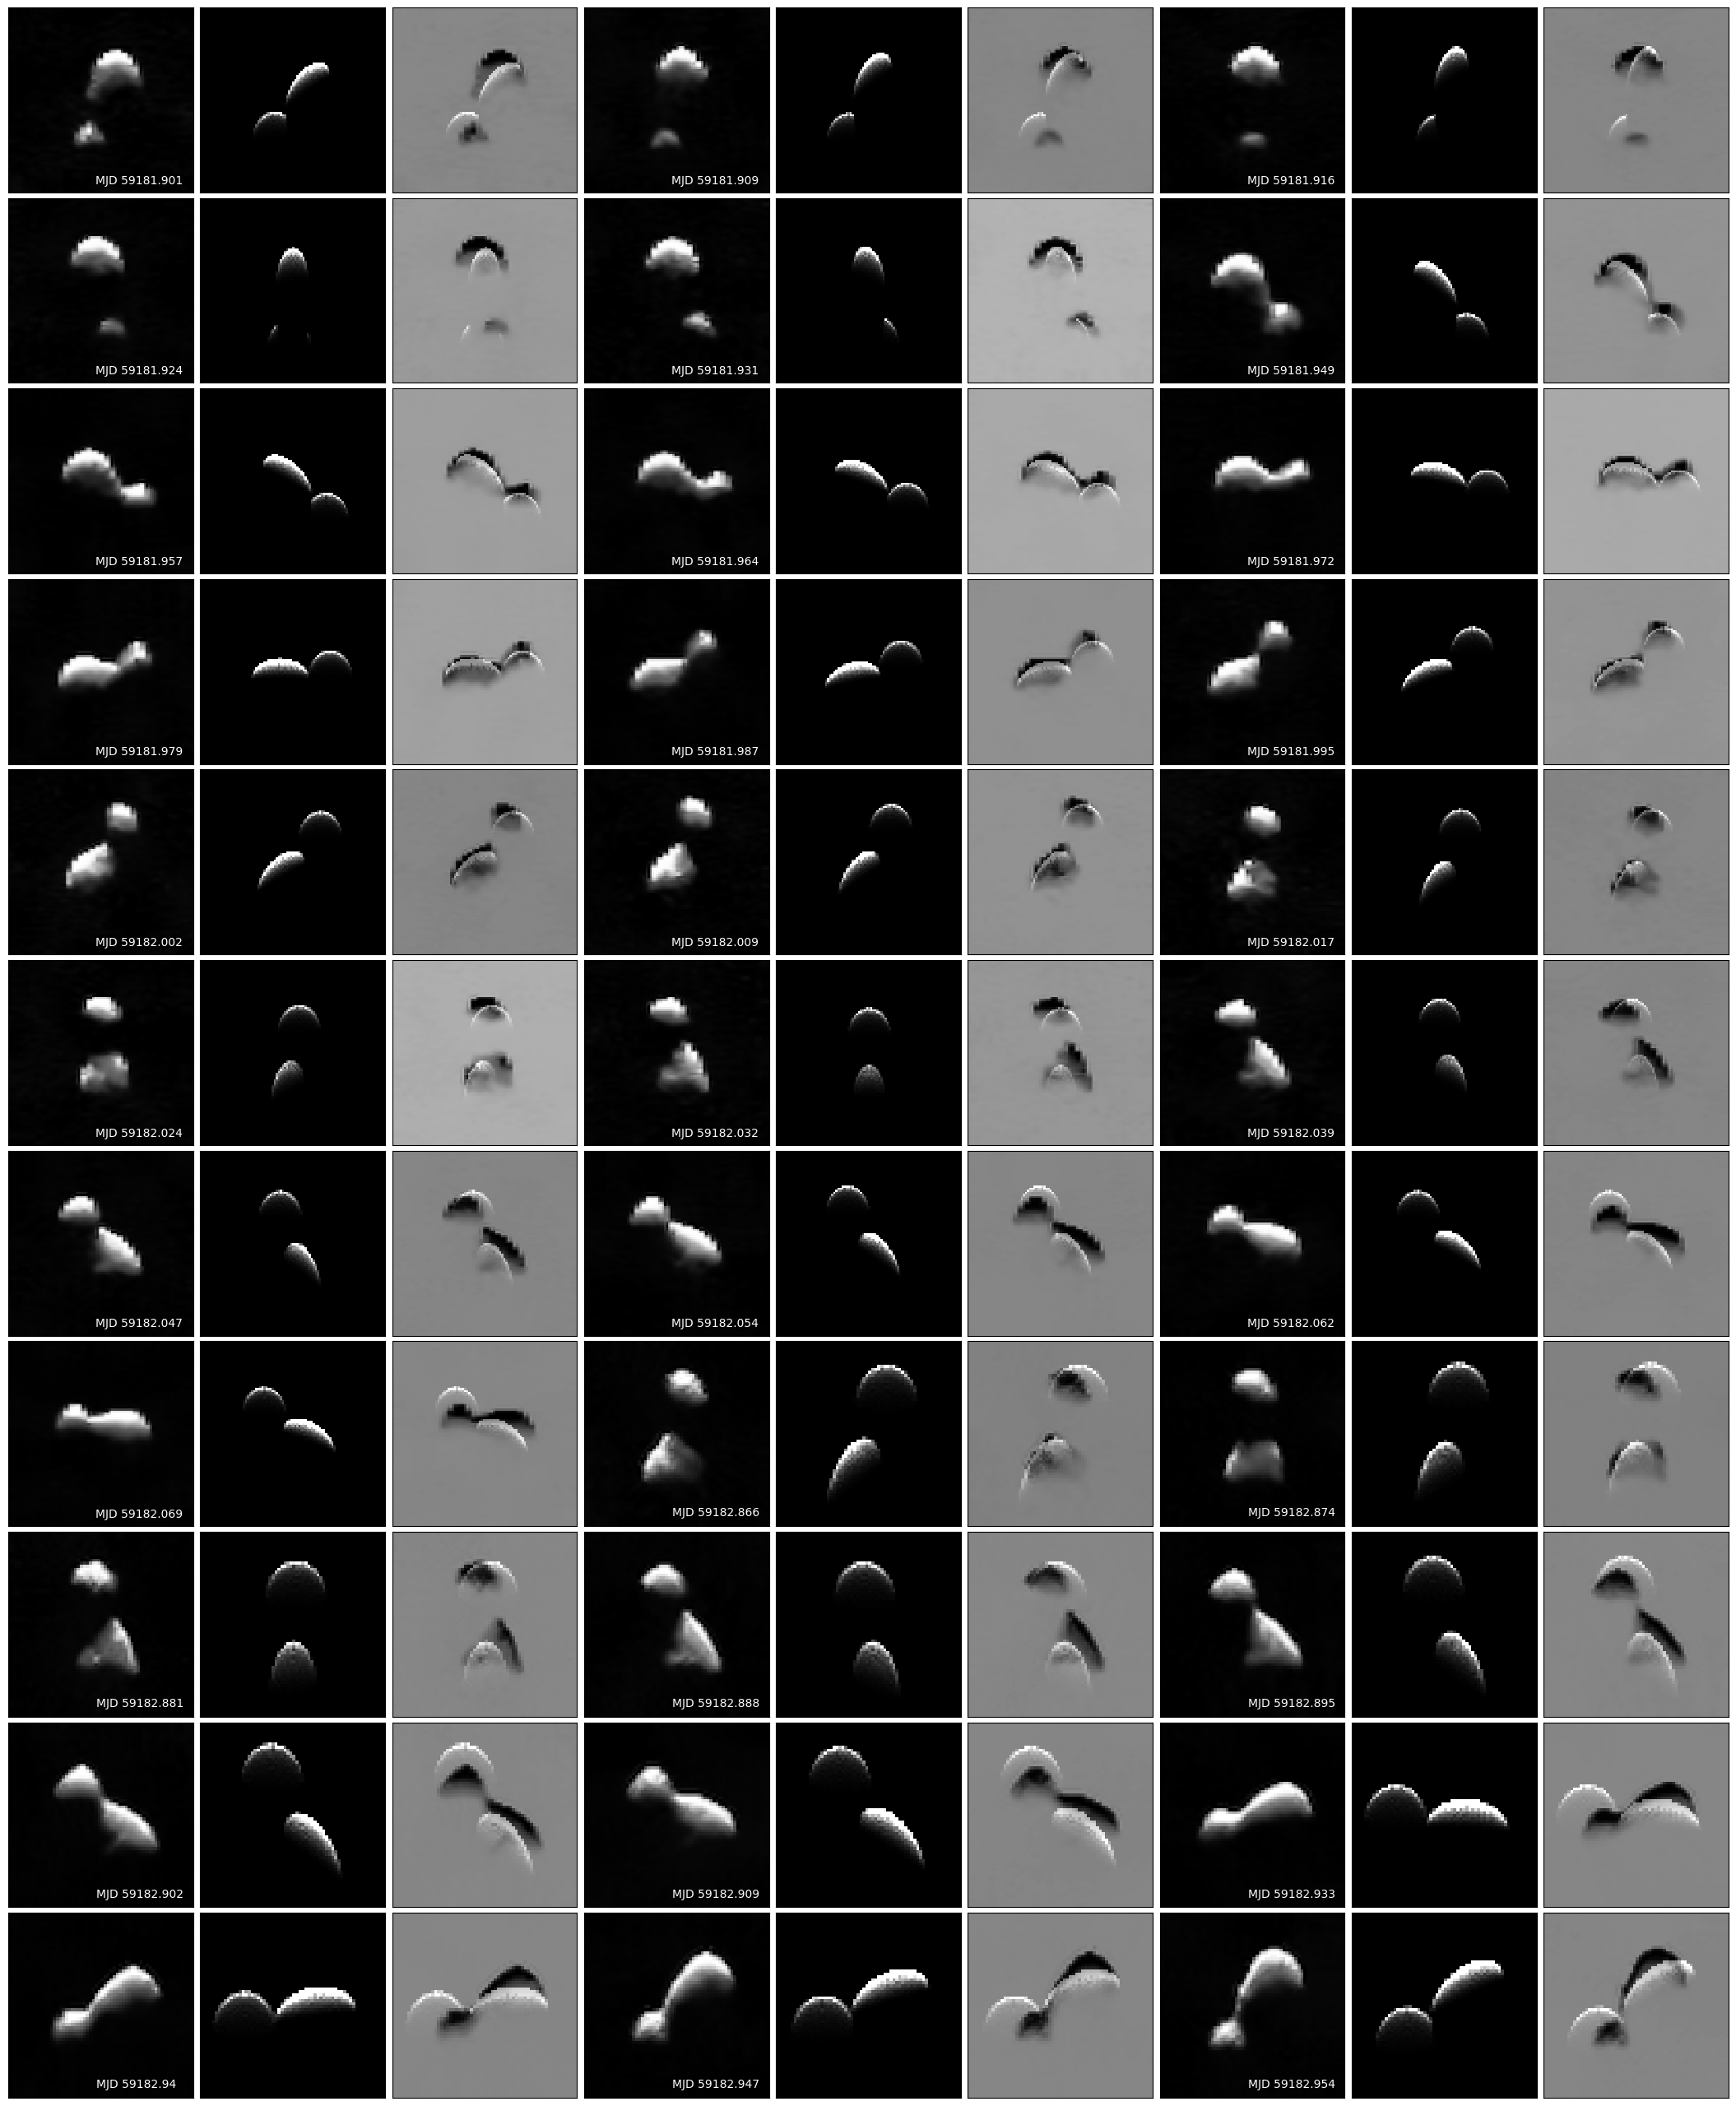

In [15]:
radar_plt = plot_radar_gray_images(imgs[:35], radar_image_params[:35], num_cols=3, dpi=100, figsize=(3,3))

In [152]:
radar_plt.savefig('article_images/radar_diff_one.pdf', dpi=100, bbox_inches='tight')

In [ ]:
fig = rf.plot_radar_rgb_images(imgs, radar_image_params, rows=10, cols=7)

In [ ]:
boot_bounds_min = np.min(np.array(boot_params)[:, :-1], axis=0)
boot_bounds_max = np.max(np.array(boot_params)[:, :-1], axis=0)
for res in boot_res9:
    res = res[:-1]
    print((boot_bounds_min <= res) & (res <= boot_bounds_max))

In [16]:
lightcurve_theor = theor_curve(params=best_params[:10], earth_data=earth_data, sun_data=sun_data)
# calculate how much the part of the observational curve have to be shifted up/down
lightcurve.calculate_shifts(other=lightcurve_theor)
# shift observed data (lightcurves) by the amount of vertical shift
lightcurve.shift_curves()

In [17]:
def build_lc_plots(lightcurve, sun_data, lightcurve_theor, num_rows: int, num_cols: int, figsize: tuple = (9, 4.5),
                   dpi: int = 100, show_lc_names=False, plot_errs=False):
    """Builds the plots for the lightcurves"""
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.labelsize'] = 18
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams['axes.titlesize'] = 15
    fig, axarr = plt.subplots(num_rows, num_cols, figsize=(figsize[0] * num_cols, figsize[1] * num_rows), dpi=dpi)
    for idx in range(0, len(lightcurve.lightcurves)):
        lc = lightcurve.lightcurves[idx].data
        idx_row, idx_col = idx // num_cols, idx % num_cols
        axarr[idx_row][idx_col].scatter(sun_data[idx]['reduc_epoch'], -lightcurve_theor[idx], s=8,
                                               label='model')
        if plot_errs:
            axarr[idx_row][idx_col].errorbar(sun_data[idx]['reduc_epoch'], -lightcurve.lightcurves[idx].data['mag_shifted'],
                                            yerr=lightcurve.lightcurves[idx].data['mag_err'], label='obs', fmt='.', color='tab:orange')
        else:
            axarr[idx_row][idx_col].scatter(sun_data[idx]['reduc_epoch'],
                                                   -lightcurve.lightcurves[idx].data['mag_shifted'], s=8, label='obs')
        axarr[idx_row][idx_col].set_xlabel('reduc_epoch [days]')
        axarr[idx_row][idx_col].set_ylabel('H [mag]')
        axarr[idx_row][idx_col].legend(loc='upper left', prop={"size": 15})
        if show_lc_names:
            axarr[idx_row][idx_col].annotate(lightcurve.lightcurves[idx].fname, xy=(0.97, 0), xycoords='axes fraction',
                                              xytext=(5, 5), textcoords='offset points', ha='right', va='bottom',
                                             fontproperties={'size': 12, 'weight': 'bold'})
        # Set x-labels to be formatted with two decimal places
        xlabels = [f'{x:.2f}' for x in axarr[idx_row][idx_col].get_xticks()]
        axarr[idx_row][idx_col].set_xticklabels(xlabels)

    return fig, axarr

/tmp/ipykernel_61763/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[idx_row][idx_col].set_xticklabels(xlabels)
/tmp/ipykernel_61763/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[idx_row][idx_col].set_xticklabels(xlabels)
/tmp/ipykernel_61763/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[idx_row][idx_col].set_xticklabels(xlabels)
/tmp/ipykernel_61763/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[idx_row][idx_col].set_xticklabels(xlabels)
/tmp/ipykernel_61763/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. afte

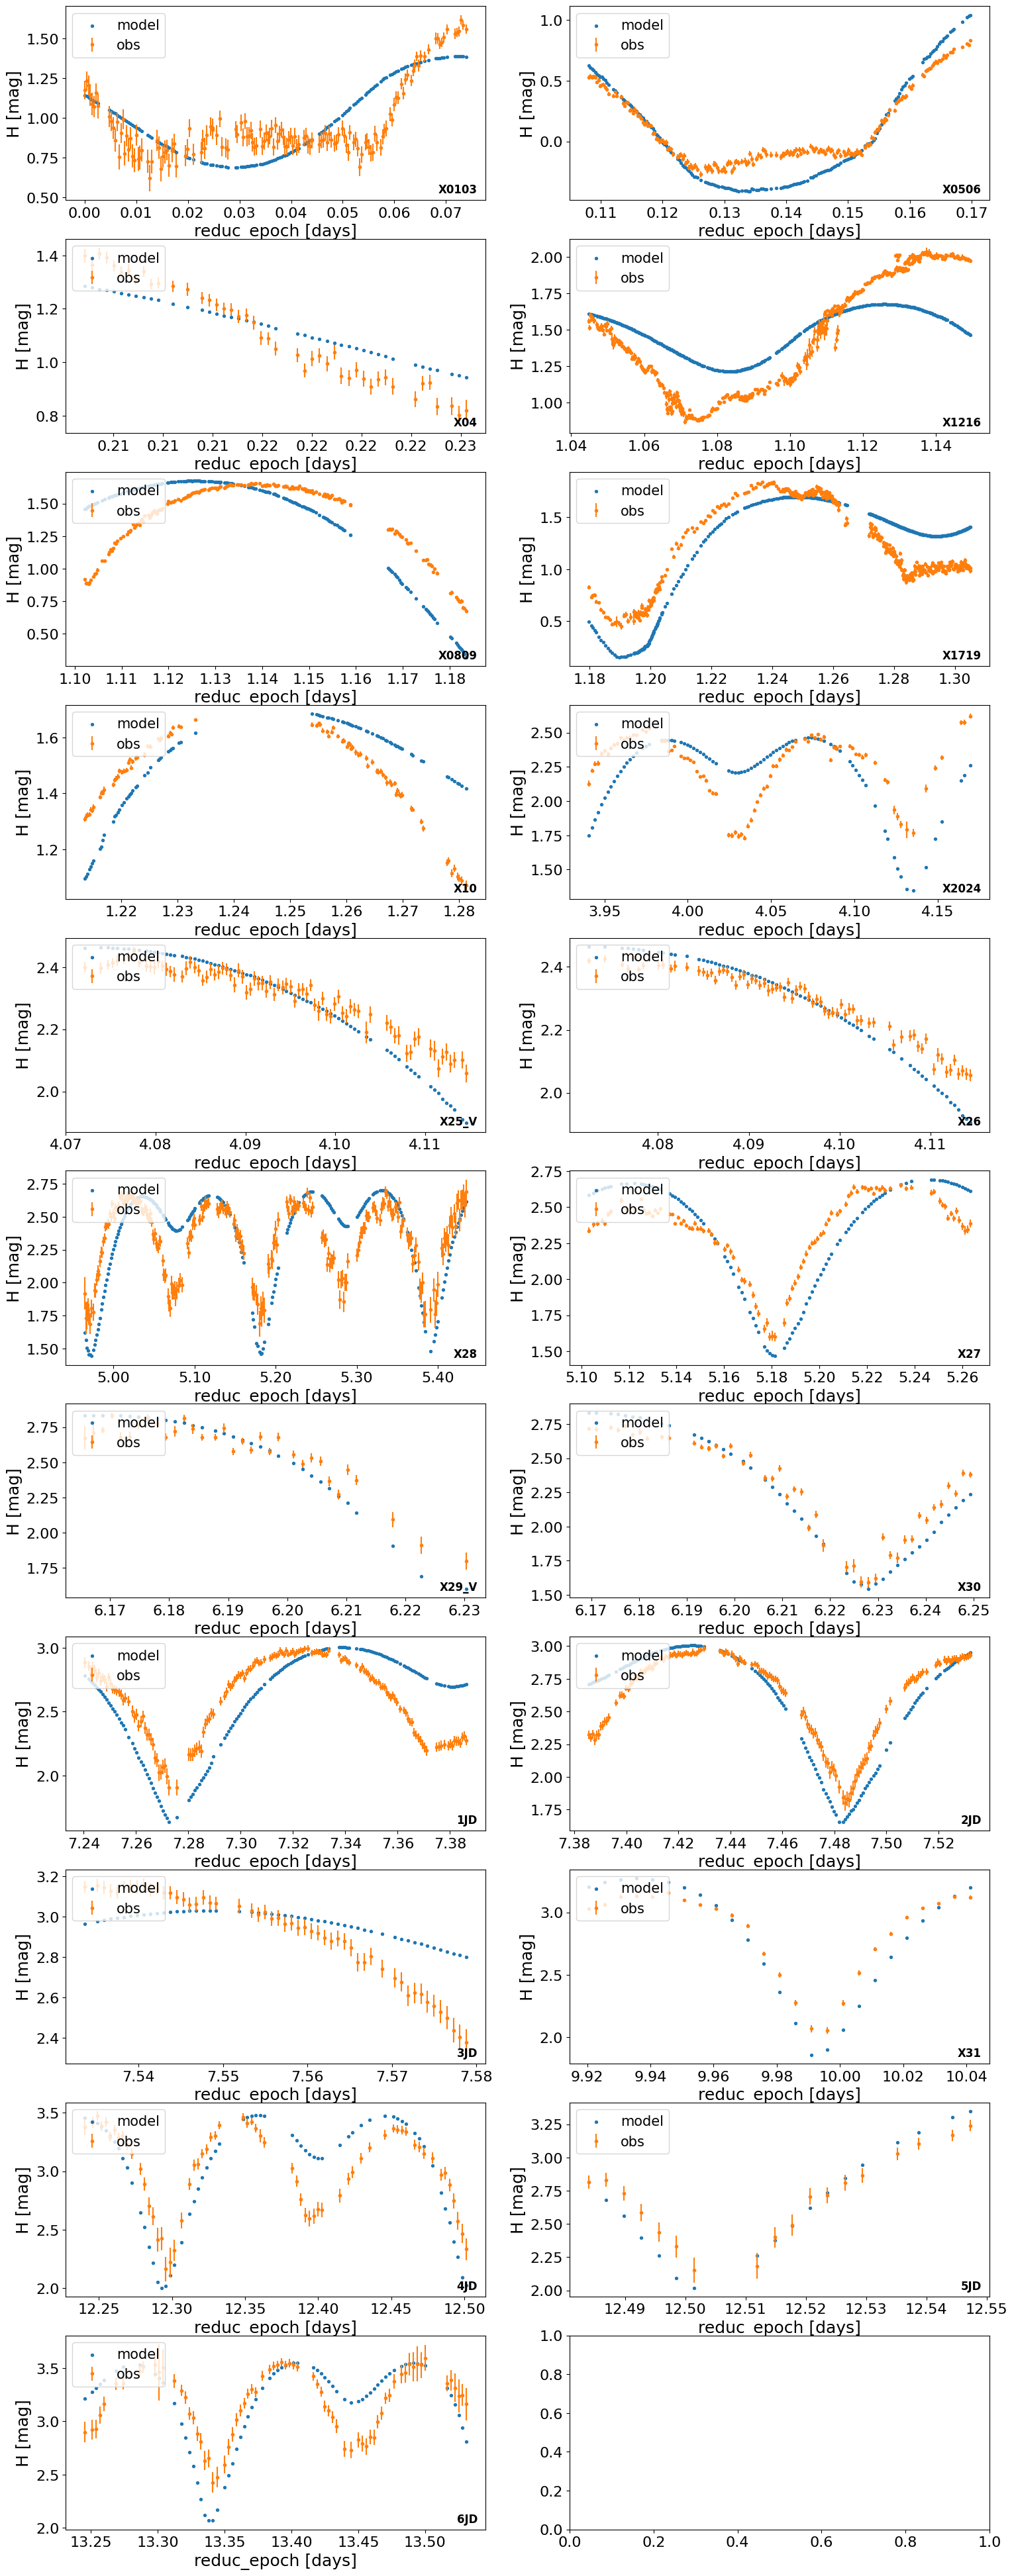

In [18]:
fig, ax = build_lc_plots(lightcurve, sun_data, lightcurve_theor, dpi=100, num_cols=2, num_rows=11, show_lc_names=True, plot_errs=True)